<a href="https://colab.research.google.com/github/Sreejabandari08/LOAN-DEFAULT-PREDICTION/blob/main/Bandari_Sreeja(236Y1A6618).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Accuracy: 0.62
Testing Accuracy: 0.57


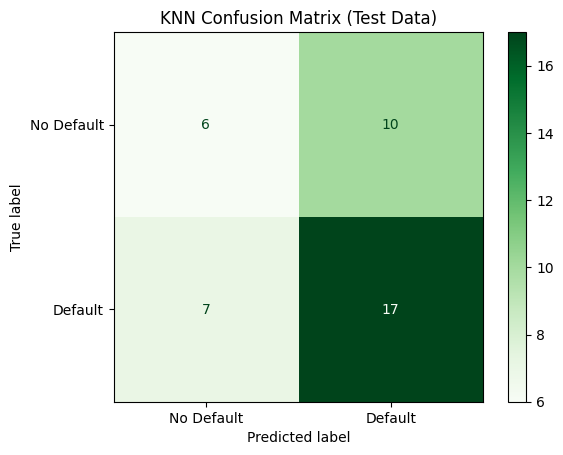

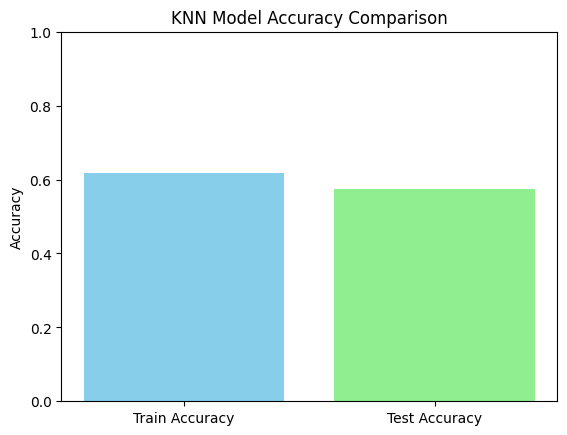

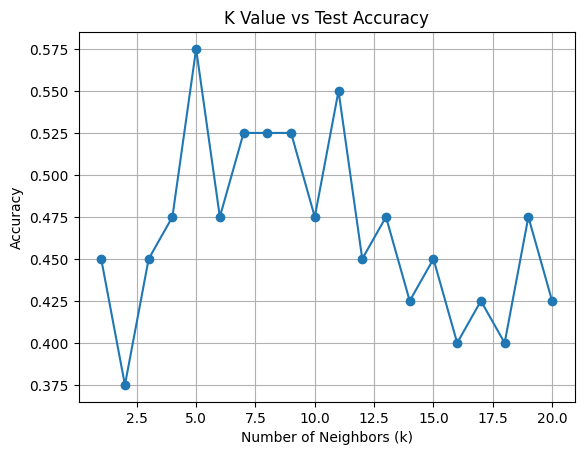

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# Step 1: Create or load dataset
# ---------------------------
# You can replace this with your CSV file, e.g.:
# df = pd.read_csv("loan_data.csv")

# Example synthetic dataset
np.random.seed(0)
df = pd.DataFrame({
    'ApplicantIncome': np.random.randint(20000, 100000, 200),
    'CreditScore': np.random.randint(300, 850, 200),
    'LoanAmount': np.random.randint(5000, 500000, 200),
    'Age': np.random.randint(20, 65, 200),
    'Default': np.random.randint(0, 2, 200)
})

# ---------------------------
# Step 2: Split data into train/test
# ---------------------------
X = df[['ApplicantIncome', 'CreditScore', 'LoanAmount', 'Age']]
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------
# Step 3: Scale the features
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# Step 4: Train KNN model
# ---------------------------
# You can experiment with k (n_neighbors)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# ---------------------------
# Step 5: Make predictions
# ---------------------------
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# ---------------------------
# Step 6: Evaluate model
# ---------------------------
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

# ---------------------------
# Step 7: Visualization
# ---------------------------

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Greens')
plt.title("KNN Confusion Matrix (Test Data)")
plt.show()

# Accuracy Comparison Bar Chart
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'lightgreen'])
plt.title('KNN Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# ---------------------------
# Step 8: Effect of K (optional)
# ---------------------------
# Plot accuracy vs K value
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.title('K Value vs Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


⚠ loan_data.csv not found — generating synthetic dataset for demo.
Data shape: (20000, 23)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f13,f14,f15,f16,f17,f18,f19,default,income_bin,age_bin
0,0.840766,-1.434832,0.286850,1.774173,-0.125365,-0.175832,2.296118,2.527308,2.908684,1.290080,...,0.743444,-3.049918,1.859750,3.853385,-0.567911,-3.405401,-1.253519,1,2,2
1,0.943659,1.566588,-0.687351,2.483048,-1.936644,0.048636,-3.673886,-0.794496,-3.762968,1.187839,...,1.206820,-0.242479,-4.155245,1.672392,0.458840,6.289368,2.902573,0,2,2
2,1.519859,0.044339,-0.366633,5.367086,1.236237,-0.665062,-2.737932,1.574536,-0.103447,-0.998418,...,0.029236,-2.252030,-0.721323,2.201121,-1.396047,2.225737,2.600777,0,3,0
3,2.613883,-1.104175,0.396758,1.132927,2.682501,-1.425784,-0.071354,2.137102,-0.283154,-0.756792,...,-1.413284,0.996409,-1.937653,-0.711261,-2.119093,-1.702025,-0.189731,0,3,1
4,-2.351389,-0.626161,2.239348,-1.838031,1.257110,-2.553392,-1.247354,3.040097,-1.130300,0.283944,...,-0.718672,0.574972,0.272822,2.570149,-1.951262,-1.444448,-0.092871,0,0,1


Numeric columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19']
Categorical columns: ['income_bin', 'age_bin']
Train size: (16000, 22) | Test size: (4000, 22)
Processed shapes: (16000, 28) (4000, 28)

🌲 Training Random Forest baseline...
RF Accuracy: 0.9607 | ROC AUC: 0.9753


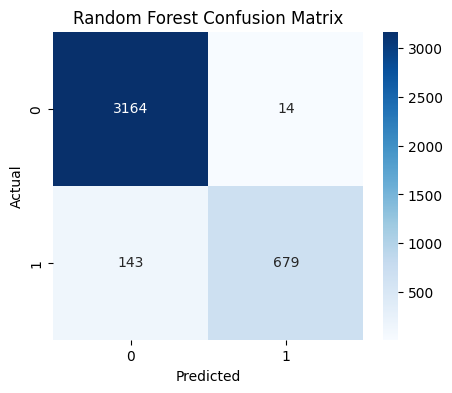


🤖 Building and training Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/40
213/213 - 3s - 13ms/step - accuracy: 0.8738 - loss: 0.3321 - val_accuracy: 0.9296 - val_loss: 0.1998
Epoch 2/40
213/213 - 1s - 3ms/step - accuracy: 0.9261 - loss: 0.2147 - val_accuracy: 0.9413 - val_loss: 0.1688
Epoch 3/40
213/213 - 1s - 3ms/step - accuracy: 0.9379 - loss: 0.1840 - val_accuracy: 0.9479 - val_loss: 0.1567
Epoch 4/40
213/213 - 1s - 3ms/step - accuracy: 0.9441 - loss: 0.1671 - val_accuracy: 0.9517 - val_loss: 0.1450
Epoch 5/40
213/213 - 1s - 3ms/step - accuracy: 0.9493 - loss: 0.1538 - val_accuracy: 0.9563 - val_loss: 0.1369
Epoch 6/40
213/213 - 1s - 6ms/step - accuracy: 0.9549 - loss: 0.1420 - val_accuracy: 0.9588 - val_loss: 0.1340
Epoch 7/40
213/213 - 1s - 3ms/step - accuracy: 0.9563 - loss: 0.1345 - val_accuracy: 0.9642 - val_loss: 0.1263
Epoch 8/40
213/213 - 1s - 3ms/step - accuracy: 0.9609 - loss: 0.1308 - val_accuracy: 0.9600 - val_loss: 0.1280
Epoch 9/40
213/213 - 1s - 3ms/step - accuracy: 0.9644 - loss: 0.1242 - val_accuracy: 0.9658 - val_loss: 0.1208


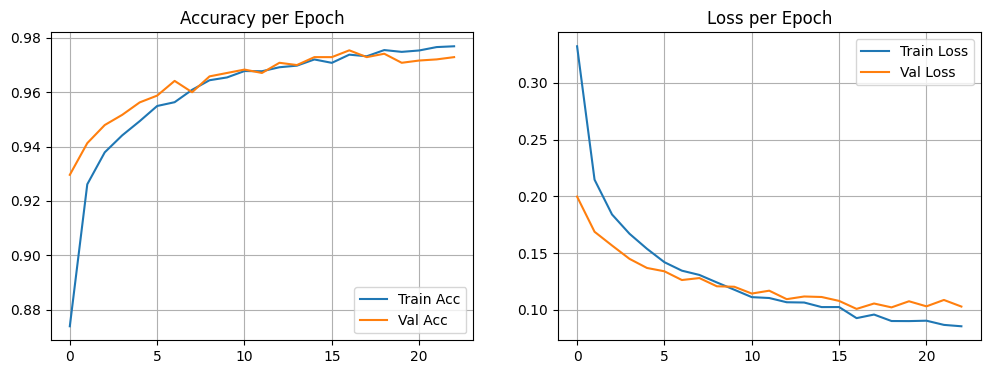

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
NN Accuracy: 0.9765 | ROC AUC: 0.9798
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      3178
           1       0.97      0.91      0.94       822

    accuracy                           0.98      4000
   macro avg       0.98      0.95      0.96      4000
weighted avg       0.98      0.98      0.98      4000



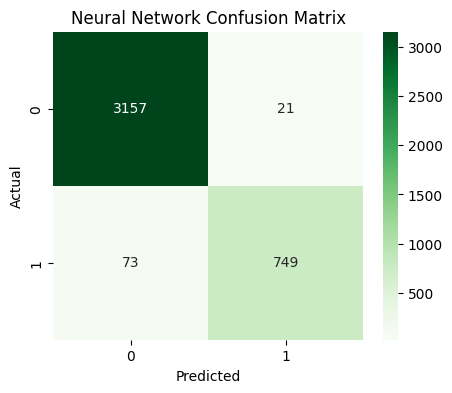

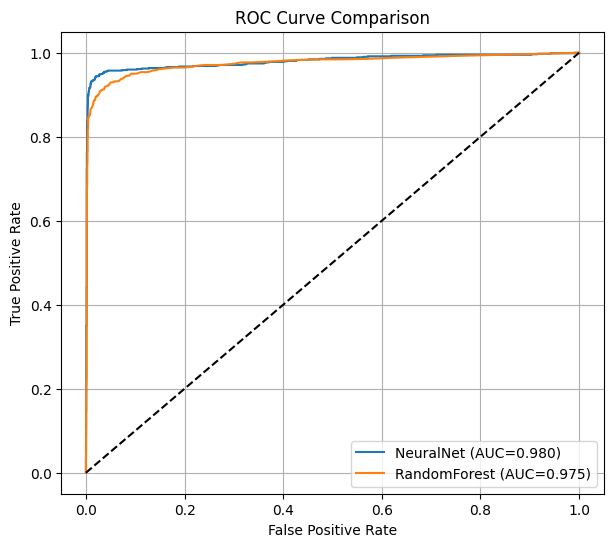


💾 Models saved: loan_nn_model.h5, loan_rf_model.joblib, preprocessor.joblib

✅ Summary:
RandomForest Accuracy=0.9607, AUC=0.9753
NeuralNet Accuracy=0.9765, AUC=0.9798


In [ ]:

# 1️⃣ Install dependencies
!pip install tensorflow scikit-learn seaborn matplotlib joblib --quiet

# 2️⃣ Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import joblib
from IPython.display import display   # ✅ Fix: proper display import

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Training configuration
EPOCHS = 40
BATCH_SIZE = 64

# 3️⃣ Load data
# Upload your own CSV to Colab as 'loan_data.csv'
DATA_FILE = 'loan_data.csv'
if os.path.exists(DATA_FILE):
    print(f"✅ Using uploaded dataset: {DATA_FILE}")
    df = pd.read_csv(DATA_FILE)
else:
    print(f"⚠ {DATA_FILE} not found — generating synthetic dataset for demo.")
    from sklearn.datasets import make_classification
    X, y = make_classification(
        n_samples=20000, n_features=20, n_informative=8,
        n_redundant=5, weights=[0.8, 0.2], flip_y=0.02,
        random_state=RANDOM_STATE
    )
    feature_names = [f"f{i}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_names)
    df["default"] = y
    df["income_bin"] = pd.qcut(df["f0"], 4, labels=False)
    df["age_bin"] = pd.qcut(np.abs(df["f1"]), 4, labels=False)

print("Data shape:", df.shape)
display(df.head())   # ✅ fixed version

# 4️⃣ Prepare data
TARGET = "default"
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Please rename your target column.")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Treat low-cardinality integer columns as categorical
for col in X.columns:
    if X[col].dtype in [np.int64, np.int32] and X[col].nunique() <= 10 and col not in categorical_cols:
        categorical_cols.append(col)
        if col in numeric_cols:
            numeric_cols.remove(col)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

# 5️⃣ Preprocessing pipeline
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# Transform data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Processed shapes:", X_train_proc.shape, X_test_proc.shape)

# 6️⃣ Random Forest Baseline
print("\n🌲 Training Random Forest baseline...")
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_proc, y_train)
y_pred_rf = rf.predict(X_test_proc)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_proc)[:, 1])
print(f"RF Accuracy: {rf_acc:.4f} | ROC AUC: {rf_auc:.4f}")

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7️⃣ Neural Network
print("\n🤖 Building and training Neural Network...")
input_dim = X_train_proc.shape[1]

def build_model(input_dim):
    model = models.Sequential([
        layers.InputLayer(input_shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(input_dim)
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

history = model.fit(
    X_train_proc, y_train,
    validation_split=0.15,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es], verbose=2
)

# 8️⃣ Plot training results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy per Epoch")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# 9️⃣ Evaluation
y_pred_proba = model.predict(X_test_proc).ravel()
y_pred_nn = (y_pred_proba >= 0.5).astype(int)

nn_acc = accuracy_score(y_test, y_pred_nn)
nn_auc = roc_auc_score(y_test, y_pred_proba)
print(f"NN Accuracy: {nn_acc:.4f} | ROC AUC: {nn_auc:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_nn))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt="d", cmap="Greens")
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔟 ROC Curve Comparison
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test_proc)[:,1])

plt.figure(figsize=(7,6))
plt.plot(fpr_nn, tpr_nn, label=f"NeuralNet (AUC={nn_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={rf_auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 11️⃣ Save models
model.save("loan_nn_model.h5")
joblib.dump(rf, "loan_rf_model.joblib")
joblib.dump(preprocessor, "preprocessor.joblib")
print("\n💾 Models saved: loan_nn_model.h5, loan_rf_model.joblib, preprocessor.joblib")

print("\n✅ Summary:")
print(f"RandomForest Accuracy={rf_acc:.4f}, AUC={rf_auc:.4f}")
print(f"NeuralNet Accuracy={nn_acc:.4f}, AUC={nn_auc:.4f}")

Training Accuracy: 0.65
Testing Accuracy: 0.57


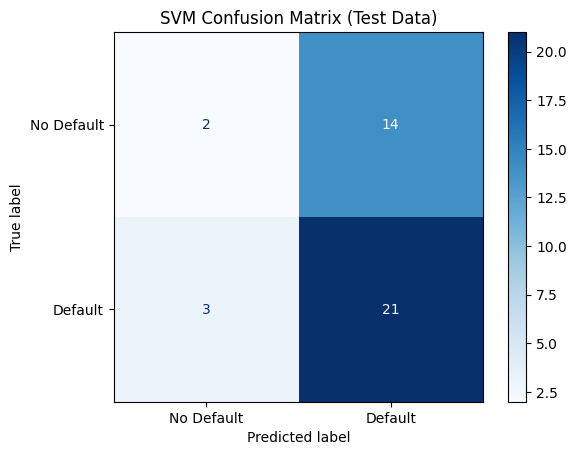

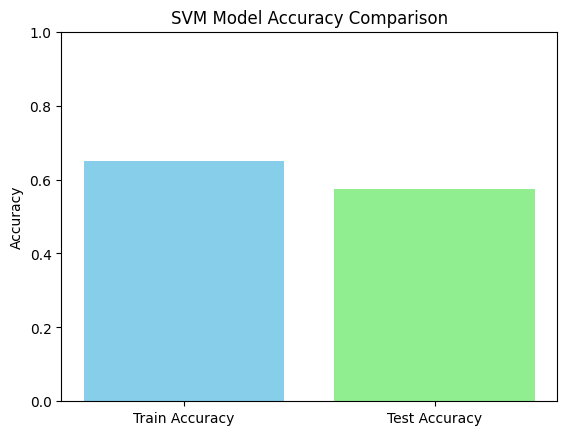

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# Step 1: Load dataset
# ---------------------------
# Replace with your file path
# df = pd.read_csv('loan_data.csv')

# Example synthetic data
np.random.seed(0)
df = pd.DataFrame({
    'ApplicantIncome': np.random.randint(20000, 100000, 200),
    'CreditScore': np.random.randint(300, 850, 200),
    'LoanAmount': np.random.randint(5000, 500000, 200),
    'Age': np.random.randint(20, 65, 200),
    'Default': np.random.randint(0, 2, 200)
})

# ---------------------------
# Step 2: Split data
# ---------------------------
X = df[['ApplicantIncome', 'CreditScore', 'LoanAmount', 'Age']]
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------
# Step 3: Feature scaling
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# Step 4: Train SVM model
# ---------------------------
model = SVC(kernel='rbf', C=1, gamma='auto')
model.fit(X_train_scaled, y_train)

# ---------------------------
# Step 5: Predict & evaluate
# ---------------------------
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

# ---------------------------
# Step 6: Visualization
# ---------------------------

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title("SVM Confusion Matrix (Test Data)")
plt.show()

# Accuracy Bar Chart
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'lightgreen'])
plt.title('SVM Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()